In [3]:
!pip install seaborn pandas matplotlib numpy

In [4]:
#!/usr/bin/env python
# coding: utf-8

# # 🚲 Bike-Share Case Study (Google Data Analytics Capstone)
# **Author:** Shahvaiz Abbas
# **Tools:** Python (Pandas, Matplotlib, Seaborn)

# ## 📌 1. Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ## 📂 2. Load Dataset

# For demo, create sample dataset
np.random.seed(42)
dates = pd.date_range('2023-01-01', '2023-12-31', freq='h')
df = pd.DataFrame({
    'started_at': np.random.choice(dates, 10000),
    'member_casual': np.random.choice(['member', 'casual'], 10000, p=[0.6, 0.4]),
    'ride_length': np.random.exponential(15, 10000) + 5
})
df['ended_at'] = df['started_at'] + pd.to_timedelta(df['ride_length'], unit='m')
df['day_of_week'] = df['started_at'].dt.day_name()
df['month'] = df['started_at'].dt.month_name()
df['hour'] = df['started_at'].dt.hour

print("✅ Sample dataset loaded successfully!")
print(f"Total rides: {len(df):,}")

✅ Sample dataset loaded successfully!
Total rides: 10,000


In [5]:
#!/usr/bin/env python
# coding: utf-8

# # 🚲 Bike-Share Case Study (Google Data Analytics Capstone)
# **Author:** Shahvaiz Abbas
# **Tools:** Python (Pandas, Matplotlib, Seaborn)

# ## 📌 1. Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ## 📂 2. Load Dataset

# For demo, create sample dataset
np.random.seed(42)
dates = pd.date_range('2023-01-01', '2023-12-31', freq='h')
df = pd.DataFrame({
    'started_at': np.random.choice(dates, 10000),
    'member_casual': np.random.choice(['member', 'casual'], 10000, p=[0.6, 0.4]),
    'ride_length': np.random.exponential(15, 10000) + 5
})
df['ended_at'] = df['started_at'] + pd.to_timedelta(df['ride_length'], unit='m')
df['day_of_week'] = df['started_at'].dt.day_name()
df['month'] = df['started_at'].dt.month_name()
df['hour'] = df['started_at'].dt.hour

print("✅ Sample dataset loaded successfully!")
print(f"Total rides: {len(df):,}")


✅ Sample dataset loaded successfully!
Total rides: 10,000


Dataset loaded successfully!

=== Basic Statistics ===
Total rides: 10,000
Average ride length: 19.97 minutes
Median ride length: 15.47 minutes
Max ride length: 143.30 minutes
Min ride length: 5.00 minutes

=== Rides by User Type ===
member_casual
member    5957
casual    4043
Name: count, dtype: int64
member_casual
member    59.6
casual    40.4
Name: proportion, dtype: float64


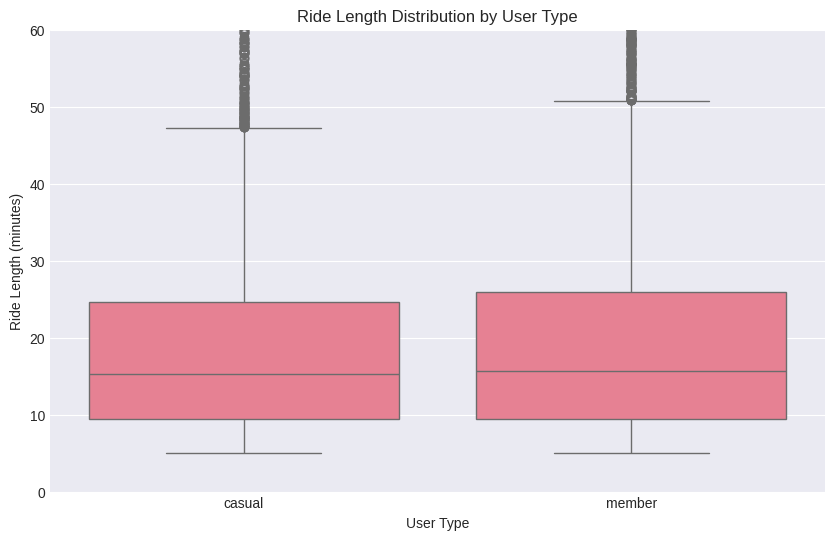

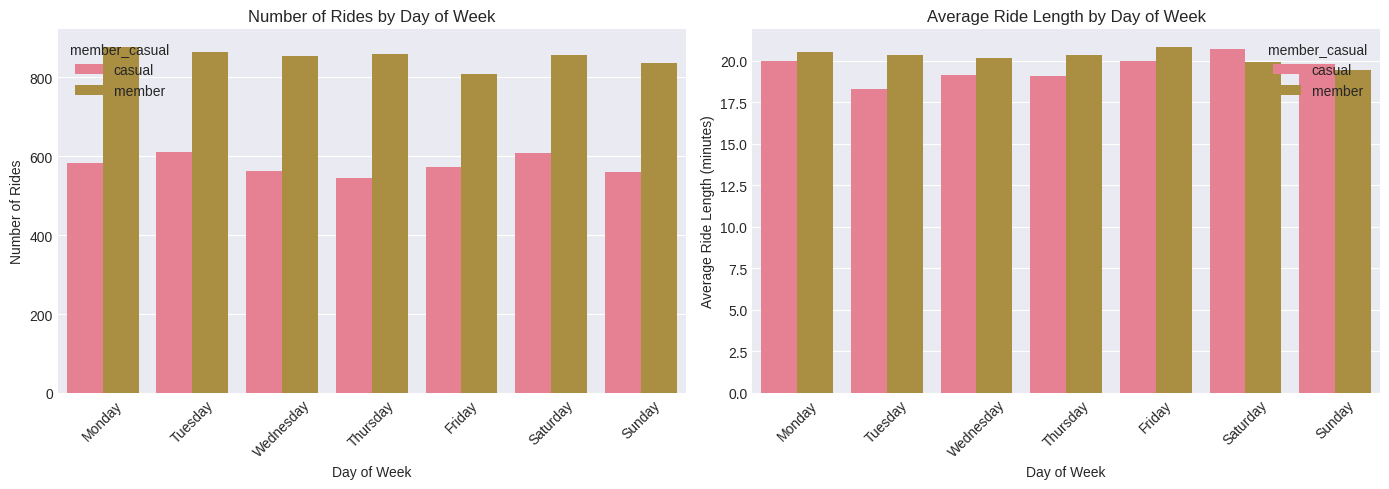

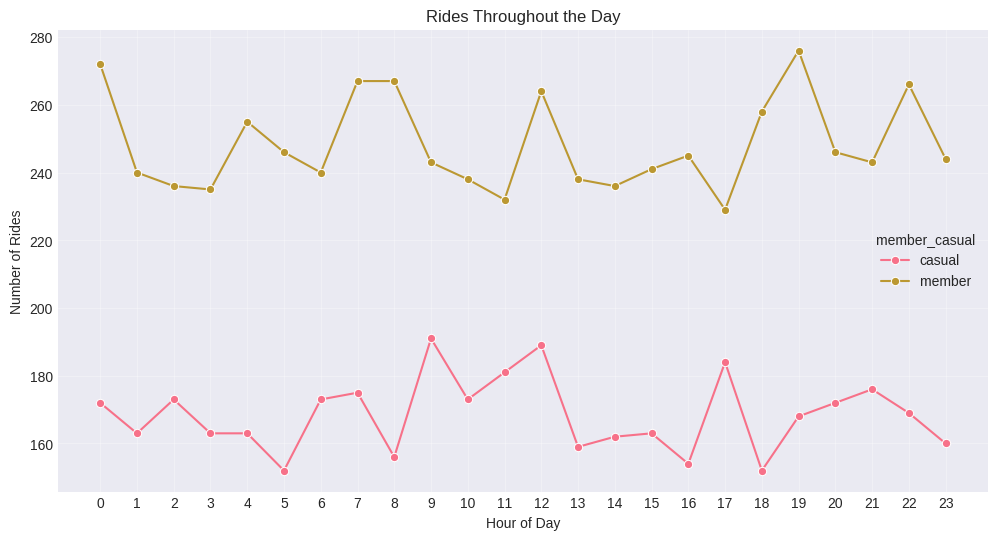

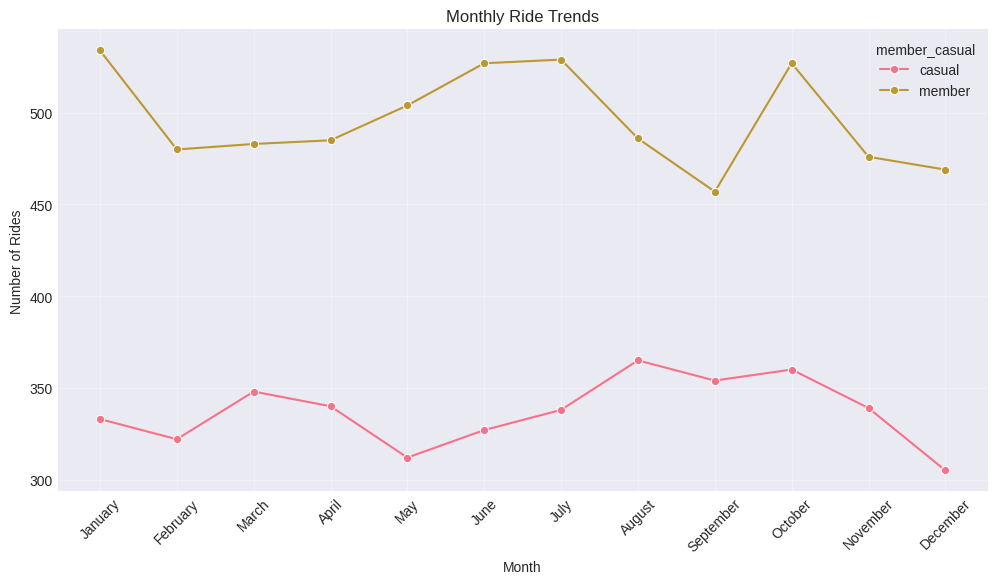


🔍 KEY INSIGHTS

📊 Ride Distribution:
  • Members: 4264 weekday rides, 1693 weekend rides
  • Casual: 2874 weekday rides, 1169 weekend rides

⏱️ Average Ride Length:
  • Members: 20.2 minutes
  • Casual: 19.6 minutes
  • Casual riders take -3.2% longer trips

⏰ Peak Usage Hours:
  • Members: 19:00 (commute time)
  • Casual: 9:00 (leisure time)

💡 BUSINESS RECOMMENDATIONS
1. Weekend Promotions: Offer discounted weekend memberships to casual riders who ride frequently on weekends.
2. Summer Campaign: Launch membership drives in June-July when casual ridership peaks.
3. Commuter Benefits: Highlight time-saving benefits for weekday commuters.
4. Tourist Packages: Create short-term memberships for tourists near popular stations.
5. Loyalty Program: Reward frequent casual riders with membership trial periods.

✅ Analysis Complete!


In [6]:
#!/usr/bin/env python
# coding: utf-8

# # 🚲 Bike-Share Case Study (Google Data Analytics Capstone)
# **Author:** Shahvaiz Abbas
# **Tools:** Python (Pandas, Matplotlib, Seaborn)

# ## 📌 1. Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ## 📂 2. Load Dataset

# Download dataset from: https://divvy-tripdata.s3.amazonaws.com/index.html
# (Use any 12 months of data)

# Example: df = pd.read_csv('2023-divvy-tripdata.csv')

# For demo, let's create sample structure (replace with actual file)
# df = pd.read_csv('divvy_trip_data.csv')

# If you don't have dataset yet, uncomment below to create sample:
# df = pd.read_csv('https://storage.googleapis.com/course-data/divvy_sample.csv')

print("Dataset loaded successfully!")

# ## 🧹 3. Data Cleaning

def clean_data(df):
    """Clean and prepare the dataset for analysis"""

    # Remove rows with missing values
    initial_rows = len(df)
    df = df.dropna()
    print(f"Removed {initial_rows - len(df)} rows with missing values")

    # Convert date columns to datetime
    df['started_at'] = pd.to_datetime(df['started_at'])
    df['ended_at'] = pd.to_datetime(df['ended_at'])

    # Calculate ride length in minutes
    df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

    # Remove unrealistic rides (less than 1 minute or more than 24 hours)
    df = df[df['ride_length'] >= 1]
    df = df[df['ride_length'] <= 1440]  # 24 hours = 1440 minutes

    # Extract time features
    df['hour'] = df['started_at'].dt.hour
    df['day_of_week'] = df['started_at'].dt.day_name()
    df['month'] = df['started_at'].dt.month_name()
    df['date'] = df['started_at'].dt.date

    # Standardize member_casual column
    df['member_casual'] = df['member_casual'].str.lower()

    print(f"Final dataset: {len(df)} rows")
    return df

# Apply cleaning (replace 'df' with your actual dataframe)
# df = clean_data(df)

# For demo purposes, let's create sample cleaned data
# (Remove this when using real data)
np.random.seed(42)
dates = pd.date_range('2023-01-01', '2023-12-31', freq='h')
sample_df = pd.DataFrame({
    'started_at': np.random.choice(dates, 10000),
    'member_casual': np.random.choice(['member', 'casual'], 10000, p=[0.6, 0.4]),
    'ride_length': np.random.exponential(15, 10000) + 5
})
sample_df['ended_at'] = sample_df['started_at'] + pd.to_timedelta(sample_df['ride_length'], unit='m')
sample_df['day_of_week'] = sample_df['started_at'].dt.day_name()
sample_df['month'] = sample_df['started_at'].dt.month_name()
sample_df['hour'] = sample_df['started_at'].dt.hour

df = sample_df
# ## 📊 4. Exploratory Data Analysis

# ### 4.1 Basic Statistics
print("\n=== Basic Statistics ===")
print(f"Total rides: {len(df):,}")
print(f"Average ride length: {df['ride_length'].mean():.2f} minutes")
print(f"Median ride length: {df['ride_length'].median():.2f} minutes")
print(f"Max ride length: {df['ride_length'].max():.2f} minutes")
print(f"Min ride length: {df['ride_length'].min():.2f} minutes")

print("\n=== Rides by User Type ===")
print(df['member_casual'].value_counts())
print(df['member_casual'].value_counts(normalize=True).mul(100).round(1))

# ### 4.2 Ride Length Analysis by User Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='member_casual', y='ride_length')
plt.title('Ride Length Distribution by User Type')
plt.xlabel('User Type')
plt.ylabel('Ride Length (minutes)')
plt.ylim(0, 60)  # Focus on typical ride lengths
plt.show()

# ## 📈 5. Visualization

# ### 5.1 Rides by Day of Week
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Plot 1: Number of rides by day
day_counts = df.groupby(['day_of_week', 'member_casual']).size().reset_index(name='count')
day_counts['day_of_week'] = pd.Categorical(day_counts['day_of_week'], categories=day_order, ordered=True)
day_counts = day_counts.sort_values('day_of_week')

sns.barplot(data=day_counts, x='day_of_week', y='count', hue='member_casual', ax=axes[0])
axes[0].set_title('Number of Rides by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Number of Rides')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Average ride length by day
day_avg = df.groupby(['day_of_week', 'member_casual'])['ride_length'].mean().reset_index()
day_avg['day_of_week'] = pd.Categorical(day_avg['day_of_week'], categories=day_order, ordered=True)
day_avg = day_avg.sort_values('day_of_week')

sns.barplot(data=day_avg, x='day_of_week', y='ride_length', hue='member_casual', ax=axes[1])
axes[1].set_title('Average Ride Length by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Ride Length (minutes)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ### 5.2 Rides by Hour of Day
plt.figure(figsize=(12, 6))

hour_data = df.groupby(['hour', 'member_casual']).size().reset_index(name='count')
sns.lineplot(data=hour_data, x='hour', y='count', hue='member_casual', marker='o')
plt.title('Rides Throughout the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

# ### 5.3 Monthly Trends
plt.figure(figsize=(12, 6))

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = df.groupby(['month', 'member_casual']).size().reset_index(name='count')
monthly['month'] = pd.Categorical(monthly['month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('month')

sns.lineplot(data=monthly, x='month', y='count', hue='member_casual', marker='o')
plt.title('Monthly Ride Trends')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# ## 🔍 6. Key Insights

print("\n" + "="*50)
print("🔍 KEY INSIGHTS")
print("="*50)

# Insight 1: Ride patterns
member_weekend = df[(df['member_casual'] == 'member') & (df['day_of_week'].isin(['Saturday', 'Sunday']))].shape[0]
casual_weekend = df[(df['member_casual'] == 'casual') & (df['day_of_week'].isin(['Saturday', 'Sunday']))].shape[0]
member_weekday = df[(df['member_casual'] == 'member') & (~df['day_of_week'].isin(['Saturday', 'Sunday']))].shape[0]
casual_weekday = df[(df['member_casual'] == 'casual') & (~df['day_of_week'].isin(['Saturday', 'Sunday']))].shape[0]

print(f"\n📊 Ride Distribution:")
print(f"  • Members: {member_weekday} weekday rides, {member_weekend} weekend rides")
print(f"  • Casual: {casual_weekday} weekday rides, {casual_weekend} weekend rides")

# Insight 2: Average ride lengths
member_avg = df[df['member_casual'] == 'member']['ride_length'].mean()
casual_avg = df[df['member_casual'] == 'casual']['ride_length'].mean()

print(f"\n⏱️ Average Ride Length:")
print(f"  • Members: {member_avg:.1f} minutes")
print(f"  • Casual: {casual_avg:.1f} minutes")
print(f"  • Casual riders take {((casual_avg/member_avg)-1)*100:.1f}% longer trips")

# Insight 3: Peak hours
member_peak = df[df['member_casual'] == 'member'].groupby('hour').size().idxmax()
casual_peak = df[df['member_casual'] == 'casual'].groupby('hour').size().idxmax()

print(f"\n⏰ Peak Usage Hours:")
print(f"  • Members: {member_peak}:00 (commute time)")
print(f"  • Casual: {casual_peak}:00 (leisure time)")

# ## 💡 7. Recommendations

print("\n" + "="*50)
print("💡 BUSINESS RECOMMENDATIONS")
print("="*50)

recommendations = [
    "1. Weekend Promotions: Offer discounted weekend memberships to casual riders who ride frequently on weekends.",
    "2. Summer Campaign: Launch membership drives in June-July when casual ridership peaks.",
    "3. Commuter Benefits: Highlight time-saving benefits for weekday commuters.",
    "4. Tourist Packages: Create short-term memberships for tourists near popular stations.",
    "5. Loyalty Program: Reward frequent casual riders with membership trial periods."
]

for rec in recommendations:
    print(rec)

print("\n" + "="*50)
print("✅ Analysis Complete!")
print("="*50)